# Лабораторная работа №6
## Задача кластеризации в финансах: сегментация клиентов банка по данным кредитных карт


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import (
    KMeans, MeanShift, estimate_bandwidth,
    DBSCAN, AffinityPropagation
)
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import time

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print('Все библиотеки загружены.')

Все библиотеки загружены.


---
## Задание 1. Первичный анализ данных

Загружаем CSV, проверяем пропуски, строим гистограммы для ключевых денежных признаков и тепловую карту корреляций.

In [2]:
df = pd.read_csv('CC_GENERAL.csv')
print(f'Размерность датасета: {df.shape[0]} клиентов, {df.shape[1]} признаков')
df.head()

Размерность датасета: 8950 клиентов, 18 признаков


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [4]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
BALANCE,8950.0,1564.47,2081.53,0.00,128.28,873.39,2054.14,19043.14
BALANCE_FREQUENCY,8950.0,0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,8950.0,1003.20,2136.63,0.00,39.64,361.28,1110.13,49039.57
ONEOFF_PURCHASES,8950.0,592.44,1659.89,0.00,0.00,38.00,577.40,40761.25
INSTALLMENTS_PURCHASES,8950.0,411.07,904.34,0.00,0.00,89.00,468.64,22500.00
CASH_ADVANCE,8950.0,978.87,2097.16,0.00,0.00,0.00,1113.82,47137.21
PURCHASES_FREQUENCY,8950.0,0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,8950.0,0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,8950.0,0.36,0.40,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,8950.0,0.14,0.20,0.00,0.00,0.00,0.22,1.50


### Гистограммы распределения ключевых денежных признаков


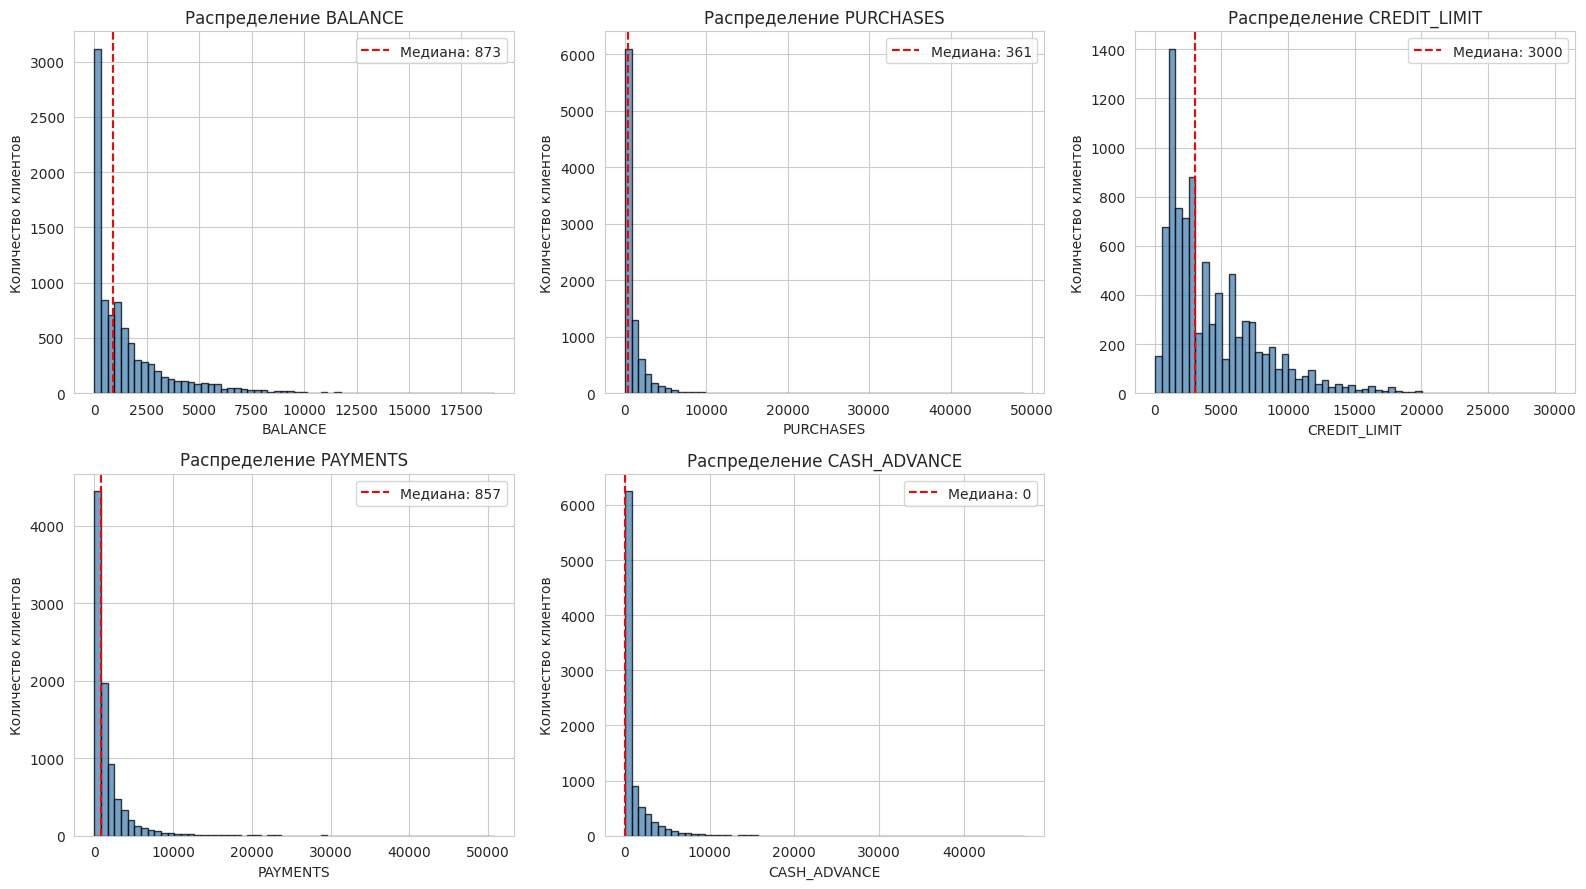

In [6]:
hist_features = ['BALANCE', 'PURCHASES', 'CREDIT_LIMIT', 'PAYMENTS', 'CASH_ADVANCE']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(hist_features):
    axes[i].hist(df[feat].dropna(), bins=60, color='steelblue', edgecolor='black', alpha=0.75)
    axes[i].set_title(f'Распределение {feat}', fontsize=12)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Количество клиентов')
    axes[i].axvline(df[feat].median(), color='red', linestyle='--',
                    label=f'Медиана: {df[feat].median():.0f}')
    axes[i].legend()

axes[-1].axis('off')
plt.tight_layout()
plt.show()

###  Матрица корреляций

Строим тепловую карту попарных корреляций Пирсона для всех числовых признаков

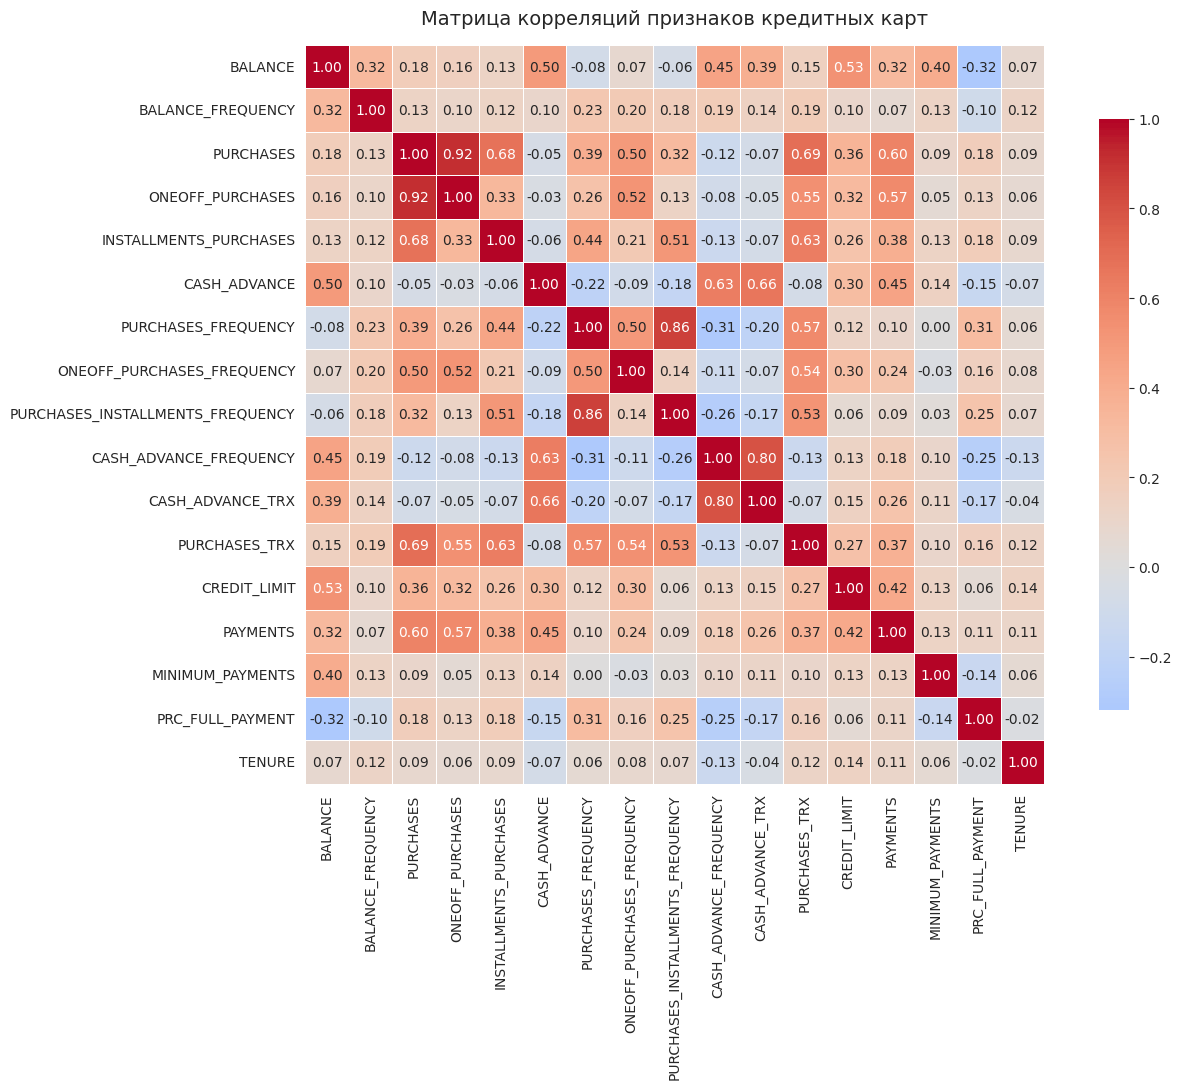

In [7]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций признаков кредитных карт', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

---
## Задание 2. Предобработка данных


In [8]:
# 2.1 Удаляем идентификатор
df_proc = df.drop('CUST_ID', axis=1).copy()
print(f'После удаления CUST_ID: {df_proc.shape}')

После удаления CUST_ID: (8950, 17)


In [9]:
# 2.2 Заполнение пропусков медианой
for col in ['MINIMUM_PAYMENTS', 'CREDIT_LIMIT']:
    median_val = df_proc[col].median()
    df_proc[col] = df_proc[col].fillna(median_val)
    print(f'{col}: пропуски заполнены медианой = {median_val:.2f}')

MINIMUM_PAYMENTS: пропуски заполнены медианой = 312.34
CREDIT_LIMIT: пропуски заполнены медианой = 3000.00


### 2.3 Удаление выбросов по стандартизованной оценке (z-score)


In [10]:
# Копия данных до удаления выбросов
df_before = df_proc.copy()

outlier_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE']

# Маска строк, которые проходят фильтр по всем трём признакам
mask = pd.Series(True, index=df_proc.index)
for col in outlier_features:
    z = np.abs((df_proc[col] - df_proc[col].mean()) / df_proc[col].std())
    mask &= (z <= 3)

df_proc = df_proc[mask].reset_index(drop=True)

print(f'До удаления выбросов: {len(df_before)} клиентов')
print(f'После удаления:      {len(df_proc)} клиентов')
print(f'Удалено:             {len(df_before) - len(df_proc)} клиентов '
      f'({(1 - len(df_proc)/len(df_before))*100:.2f}%)')

До удаления выбросов: 8950 клиентов
После удаления:      8499 клиентов
Удалено:             451 клиентов (5.04%)


### 2.4 Boxplot до и после

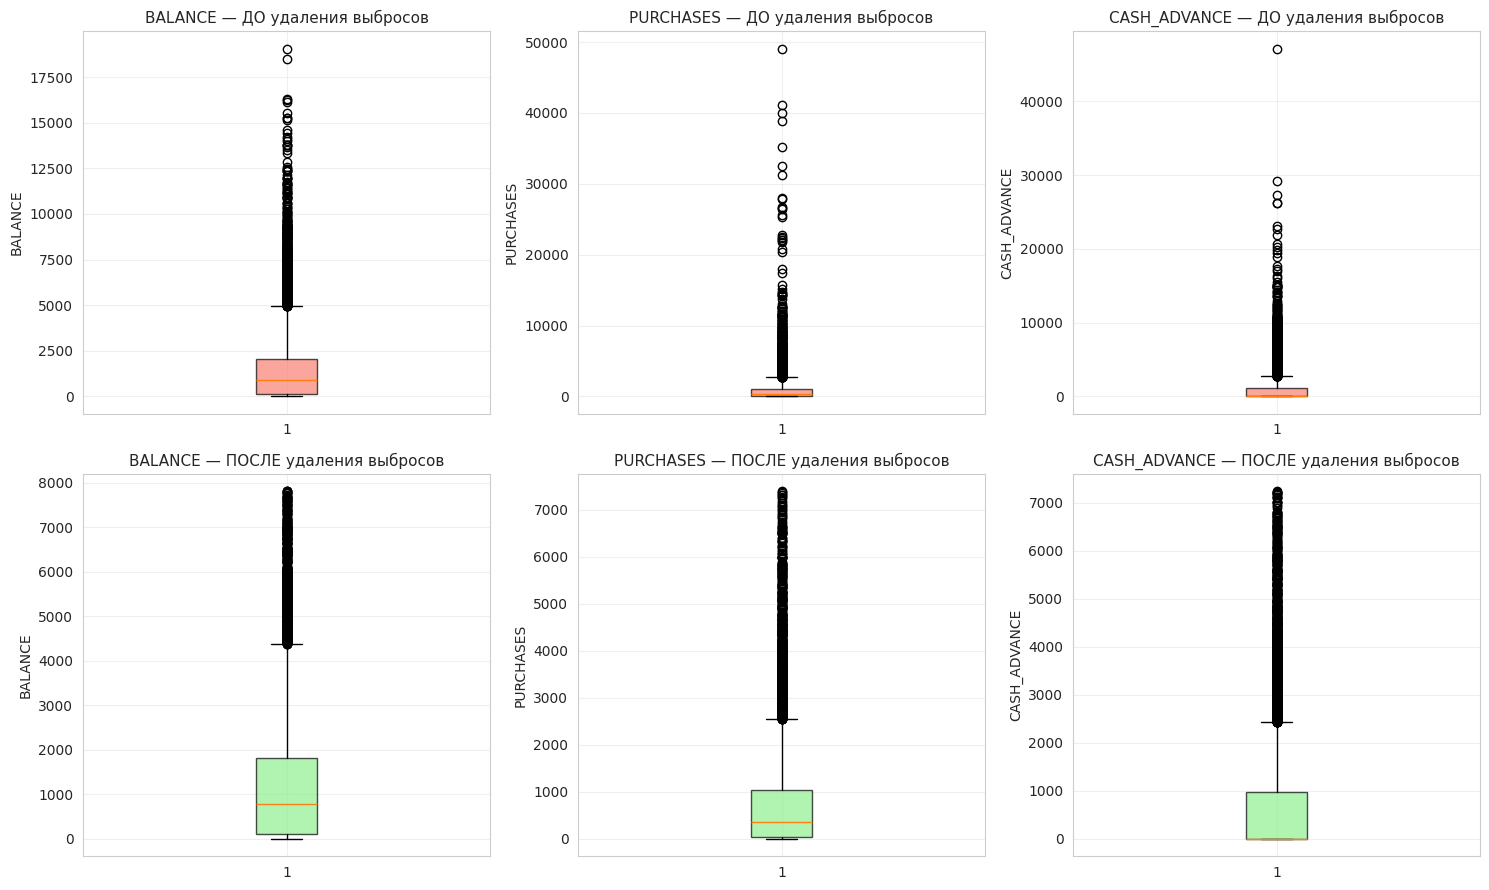

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for i, col in enumerate(outlier_features):
    # До
    axes[0, i].boxplot(df_before[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='salmon', alpha=0.7))
    axes[0, i].set_title(f'{col} — ДО удаления выбросов', fontsize=11)
    axes[0, i].set_ylabel(col)
    axes[0, i].grid(alpha=0.3)

    # После
    axes[1, i].boxplot(df_proc[col], vert=True, patch_artist=True,
                       boxprops=dict(facecolor='lightgreen', alpha=0.7))
    axes[1, i].set_title(f'{col} — ПОСЛЕ удаления выбросов', fontsize=11)
    axes[1, i].set_ylabel(col)
    axes[1, i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 2.5 Стандартизация



In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_proc)

# Сохраним и как DataFrame для удобства
X_scaled_df = pd.DataFrame(X_scaled, columns=df_proc.columns)

print(f'Форма масштабированных данных: {X_scaled.shape}')
print(f'Проверка: среднее ≈ 0, std ≈ 1')
print(X_scaled_df.describe().loc[['mean', 'std']].round(4))

Форма масштабированных данных: (8499, 17)
Проверка: среднее ≈ 0, std ≈ 1
      BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
mean   0.0000             0.0000    -0.0000            0.0000   
std    1.0001             1.0001     1.0001            1.0001   

      INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
mean                 -0.0000        0.0000              -0.0000   
std                   1.0001        1.0001               1.0001   

      ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
mean                      0.0000                           -0.0000   
std                       1.0001                            1.0001   

      CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX  PURCHASES_TRX  CREDIT_LIMIT  \
mean                 -0.0000           -0.0000        -0.0000        0.0000   
std                   1.0001            1.0001         1.0001        1.0001   

      PAYMENTS  MINIMUM_PAYMENTS  PRC_FULL_PAYMENT  TENURE  
mean   -0.0000     

---
## Задание 3. K-Means с n_clusters=4


In [13]:
kmeans4 = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
cluster_labels_4 = kmeans4.fit_predict(X_scaled)

# Добавляем метки в исходный (очищенный) датасет
df_proc['Cluster'] = cluster_labels_4

print('Распределение клиентов по кластерам (K=4):')
cluster_counts = df_proc['Cluster'].value_counts().sort_index()
for c, n in cluster_counts.items():
    print(f'  Кластер {c}: {n:>5} клиентов ({n/len(df_proc)*100:.1f}%)')

print(f'Silhouette Score (K=4): {silhouette_score(X_scaled, cluster_labels_4):.4f}')
print(f'Inertia (K=4):          {kmeans4.inertia_:.1f}')

Распределение клиентов по кластерам (K=4):
  Кластер 0:  1335 клиентов (15.7%)
  Кластер 1:  3479 клиентов (40.9%)
  Кластер 2:   988 клиентов (11.6%)
  Кластер 3:  2697 клиентов (31.7%)
Silhouette Score (K=4): 0.1808
Inertia (K=4):          90716.6


### 3.1 Визуализация кластеров в пространстве первых двух главных компонент


Доля объяснённой дисперсии:
  PC1: 28.0%
  PC2: 19.1%
  Итого в 2D: 47.1%


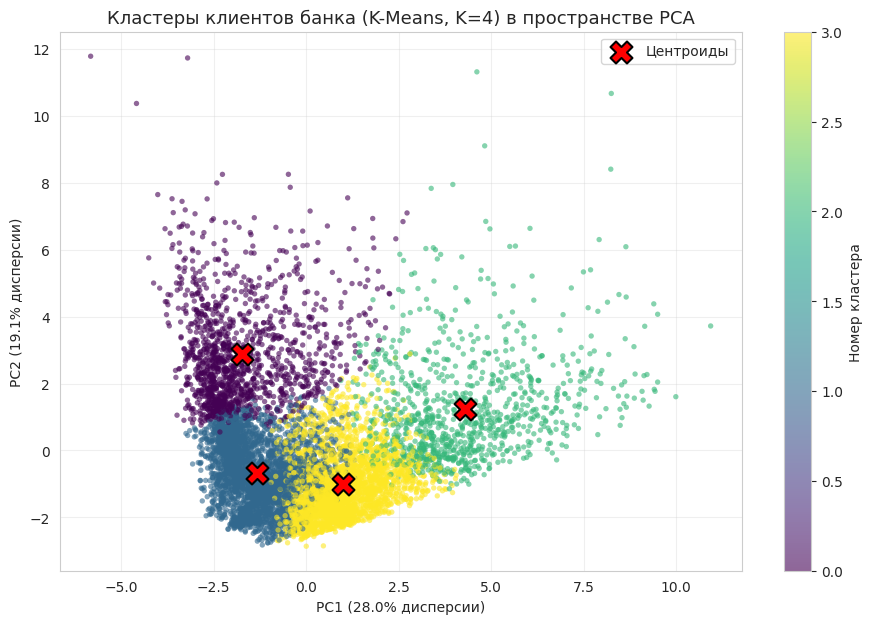

In [14]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

print(f'Доля объяснённой дисперсии:')
print(f'  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%')
print(f'  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'  Итого в 2D: {pca.explained_variance_ratio_.sum()*100:.1f}%')

plt.figure(figsize=(11, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                      c=cluster_labels_4, cmap='viridis',
                      s=15, alpha=0.6, edgecolors='none')

# Центроиды в пространстве PCA
centroids_pca = pca.transform(kmeans4.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='red', marker='X', s=250,
            edgecolors='black', linewidths=1.5, label='Центроиды')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)')
plt.title('Кластеры клиентов банка (K-Means, K=4) в пространстве PCA', fontsize=13)
plt.colorbar(scatter, label='Номер кластера')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

---
## Задание 4. Подбор оптимального K



In [15]:
# Готовим чистый массив для K-Means (без колонки Cluster, которую добавили в шаге 3)
X_for_kmeans = X_scaled  # это уже np.array без Cluster

K_range = range(2, 11)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lab = km.fit_predict(X_for_kmeans)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_for_kmeans, lab))
    print(f'K={k:2d}: inertia = {km.inertia_:>10.1f}, silhouette = {silhouettes[-1]:.4f}')

K= 2: inertia =   118026.2, silhouette = 0.2083
K= 3: inertia =   101487.0, silhouette = 0.2212
K= 4: inertia =    90716.6, silhouette = 0.1808
K= 5: inertia =    84393.1, silhouette = 0.1812
K= 6: inertia =    79098.9, silhouette = 0.1917
K= 7: inertia =    74317.0, silhouette = 0.2027
K= 8: inertia =    69297.7, silhouette = 0.2085
K= 9: inertia =    66480.8, silhouette = 0.2085
K=10: inertia =    63867.9, silhouette = 0.2026


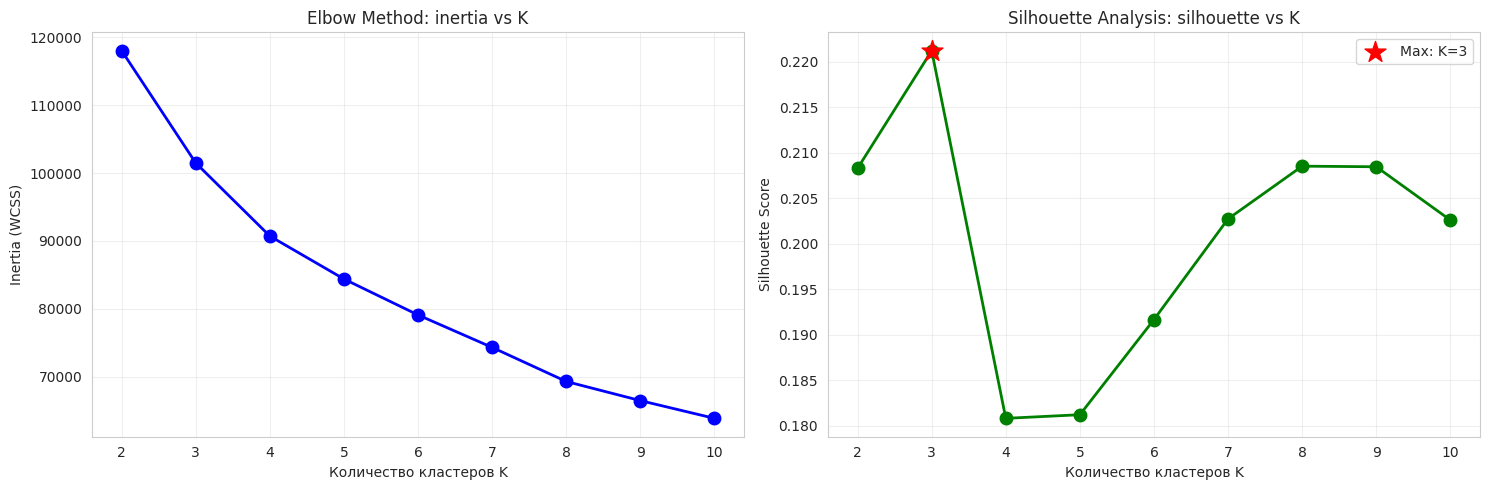

Оптимальное K по максимуму Silhouette: K = 3 (silhouette = 0.2212)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow
axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=9)
axes[0].set_xlabel('Количество кластеров K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method: inertia vs K')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(list(K_range))

# Silhouette
axes[1].plot(list(K_range), silhouettes, 'go-', linewidth=2, markersize=9)
best_k_idx = int(np.argmax(silhouettes))
best_k = list(K_range)[best_k_idx]
axes[1].scatter([best_k], [silhouettes[best_k_idx]],
                color='red', s=250, marker='*',
                zorder=5, label=f'Max: K={best_k}')
axes[1].set_xlabel('Количество кластеров K')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis: silhouette vs K')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(list(K_range))

plt.tight_layout()
plt.show()

print(f'Оптимальное K по максимуму Silhouette: K = {best_k} '
      f'(silhouette = {max(silhouettes):.4f})')

### Промежуточные результаты

**Метод локтя:** кривая inertia монотонно убывает. Наиболее заметный "слом" в темпе падения приходится примерно на **K=3** — после него inertia снижается почти линейно и гораздо медленнее. Это сигнал, что добавление кластеров сверх 3 уже не даёт существенного выигрыша в компактности.

**Анализ силуэта:** максимум Silhouette Score достигается при K=3 (≈ 0.21). Значения силуэта на всём диапазоне K невысокие (0.18–0.22) — это норма для реальных финансовых данных: клиенты банка образуют континуум поведений, а не чётко отделённые группы. В методичке K-Means на синтетических блобах давал силуэт ~0.59, здесь реальные данные существенно сложнее.

**Итоговый выбор: K = 3.**

In [17]:
OPTIMAL_K = 3
print(f'Финальное значение K для задания 5: {OPTIMAL_K}')

Финальное значение K для задания 5: 3


---
## Задание 5. Сравнение трёх алгоритмов: Mean Shift, DBSCAN, Affinity Propagation цифры 2, 5, 7


Метрики качества:
- **Silhouette Score** ( лучше, диапазон −1..1): соответствие объекта своему кластеру.
- **Davies-Bouldin Index** ( лучше): среднее сходство между ближайшими кластерами.
- **Calinski-Harabasz Score** ( лучше): отношение межкластерной дисперсии к внутрикластерной.

### 5.1 Mean Shift

Подбираем bandwidth автоматически через estimate_bandwidth. На полных 8400+ точках оценка на всей выборке медленная, используем подвыборку 1000 точек.

In [18]:
print('Оценка параметра bandwidth')
bandwidth = estimate_bandwidth(X_scaled, quantile=0.2, n_samples=1000, random_state=RANDOM_STATE)
print(f'bandwidth = {bandwidth:.4f}')

print('Запуск Mean Shift')
t0 = time.time()
ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels_ms = ms.fit_predict(X_scaled)
time_ms = time.time() - t0

n_clusters_ms = len(np.unique(labels_ms))
print(f'Время: {time_ms:.2f} сек')
print(f'Найдено кластеров: {n_clusters_ms}')

# Метрики
sil_ms = silhouette_score(X_scaled, labels_ms)
db_ms  = davies_bouldin_score(X_scaled, labels_ms)
ch_ms  = calinski_harabasz_score(X_scaled, labels_ms)

print(f'Silhouette Score:        {sil_ms:.4f}')
print(f'Davies-Bouldin Index:    {db_ms:.4f}')
print(f'Calinski-Harabasz Score: {ch_ms:.2f}')

Оценка параметра bandwidth
bandwidth = 3.8291
Запуск Mean Shift
Время: 6.34 сек
Найдено кластеров: 32
Silhouette Score:        0.2699
Davies-Bouldin Index:    1.2413
Calinski-Harabasz Score: 101.94


### 5.2 DBSCAN

Подбираем параметры через **k-distance graph** — классическая эвристика для DBSCAN.

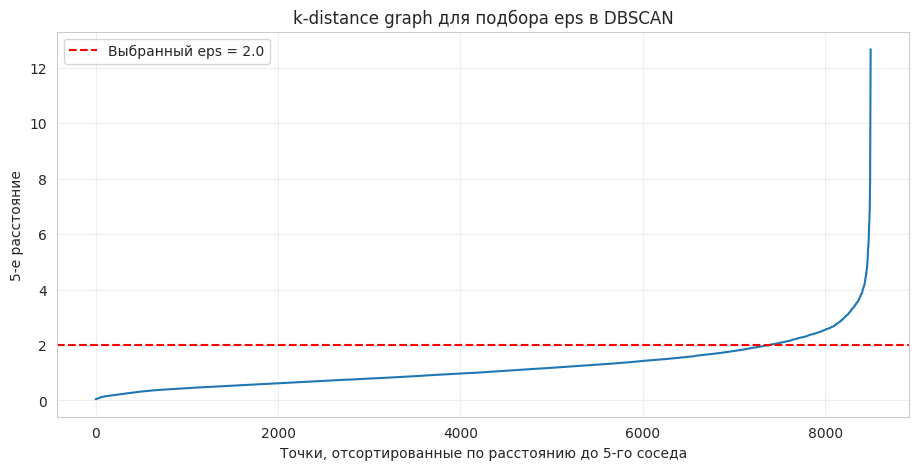

In [19]:
from sklearn.neighbors import NearestNeighbors

k_nn = 5  # соответствует min_samples
nbrs = NearestNeighbors(n_neighbors=k_nn).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(11, 5))
plt.plot(k_distances, linewidth=1.5)
plt.axhline(y=2.0, color='red', linestyle='--', label='Выбранный eps = 2.0')
plt.xlabel('Точки, отсортированные по расстоянию до 5-го соседа')
plt.ylabel(f'{k_nn}-е расстояние')
plt.title('k-distance graph для подбора eps в DBSCAN')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [20]:
print('Запуск DBSCAN')
t0 = time.time()
dbscan = DBSCAN(eps=2.0, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)
time_db = time.time() - t0

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db = int((labels_db == -1).sum())

print(f'Время: {time_db:.2f} сек')
print(f'Найдено кластеров: {n_clusters_db}')
print(f'Шумовых точек (метка -1): {n_noise_db} ({n_noise_db/len(labels_db)*100:.1f}%)')

# DBSCAN: метрики считаем только на не-шумовых точках
mask_db = labels_db != -1
if n_clusters_db >= 2 and mask_db.sum() >= 2:
    sil_db = silhouette_score(X_scaled[mask_db], labels_db[mask_db])
    db_db  = davies_bouldin_score(X_scaled[mask_db], labels_db[mask_db])
    ch_db  = calinski_harabasz_score(X_scaled[mask_db], labels_db[mask_db])
else:
    sil_db = db_db = ch_db = float('nan')

print(f'Silhouette Score:        {sil_db:.4f}  (без учёта шума)')
print(f'Davies-Bouldin Index:    {db_db:.4f}  (без учёта шума)')
print(f'Calinski-Harabasz Score: {ch_db:.2f}  (без учёта шума)')

Запуск DBSCAN
Время: 0.79 сек
Найдено кластеров: 3
Шумовых точек (метка -1): 745 (8.8%)
Silhouette Score:        0.3310  (без учёта шума)
Davies-Bouldin Index:    0.6351  (без учёта шума)
Calinski-Harabasz Score: 28.25  (без учёта шума)


### 5.3 Affinity Propagation


In [21]:
print('Запуск Affinity Propagation')
t0 = time.time()
ap = AffinityPropagation(damping=0.9, max_iter=300, random_state=RANDOM_STATE)
labels_ap = ap.fit_predict(X_scaled)
time_ap = time.time() - t0

n_clusters_ap = len(np.unique(labels_ap))
print(f'Время: {time_ap:.2f} сек')
print(f'Найдено кластеров (exemplars): {n_clusters_ap}')

if n_clusters_ap >= 2:
    sil_ap = silhouette_score(X_scaled, labels_ap)
    db_ap  = davies_bouldin_score(X_scaled, labels_ap)
    ch_ap  = calinski_harabasz_score(X_scaled, labels_ap)
else:
    sil_ap = db_ap = ch_ap = float('nan')

print(f'Silhouette Score:        {sil_ap:.4f}')
print(f'Davies-Bouldin Index:    {db_ap:.4f}')
print(f'Calinski-Harabasz Score: {ch_ap:.2f}')

Запуск Affinity Propagation
Время: 301.80 сек
Найдено кластеров (exemplars): 323
Silhouette Score:        0.1291
Davies-Bouldin Index:    1.4065
Calinski-Harabasz Score: 198.13


### 5.4 Сводная таблица сравнения

In [23]:
results = pd.DataFrame([
    {
        'Алгоритм': 'Mean Shift',
        'Время, с': round(time_ms, 2),
        'Кластеров': n_clusters_ms,
        'Шум': 0,
        'Silhouette ↑': round(sil_ms, 4),
        'Davies-Bouldin ↓': round(db_ms, 4),
        'Calinski-Harabasz ↑': round(ch_ms, 2)
    },
    {
        'Алгоритм': 'DBSCAN',
        'Время, с': round(time_db, 2),
        'Кластеров': n_clusters_db,
        'Шум': n_noise_db,
        'Silhouette ↑': round(sil_db, 4),
        'Davies-Bouldin ↓': round(db_db, 4),
        'Calinski-Harabasz ↑': round(ch_db, 2)
    },
    {
        'Алгоритм': 'Affinity Propagation',
        'Время, с': round(time_ap, 2),
        'Кластеров': n_clusters_ap,
        'Шум': 0,
        'Silhouette ↑': round(sil_ap, 4),
        'Davies-Bouldin ↓': round(db_ap, 4),
        'Calinski-Harabasz ↑': round(ch_ap, 2)
    }
])

print(results.to_string(index=False))

            Алгоритм  Время, с  Кластеров  Шум  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
          Mean Shift      6.34         32    0        0.2699            1.2413               101.94
              DBSCAN      0.79          3  745        0.3310            0.6351                28.25
Affinity Propagation    301.80        323    0        0.1291            1.4065               198.13


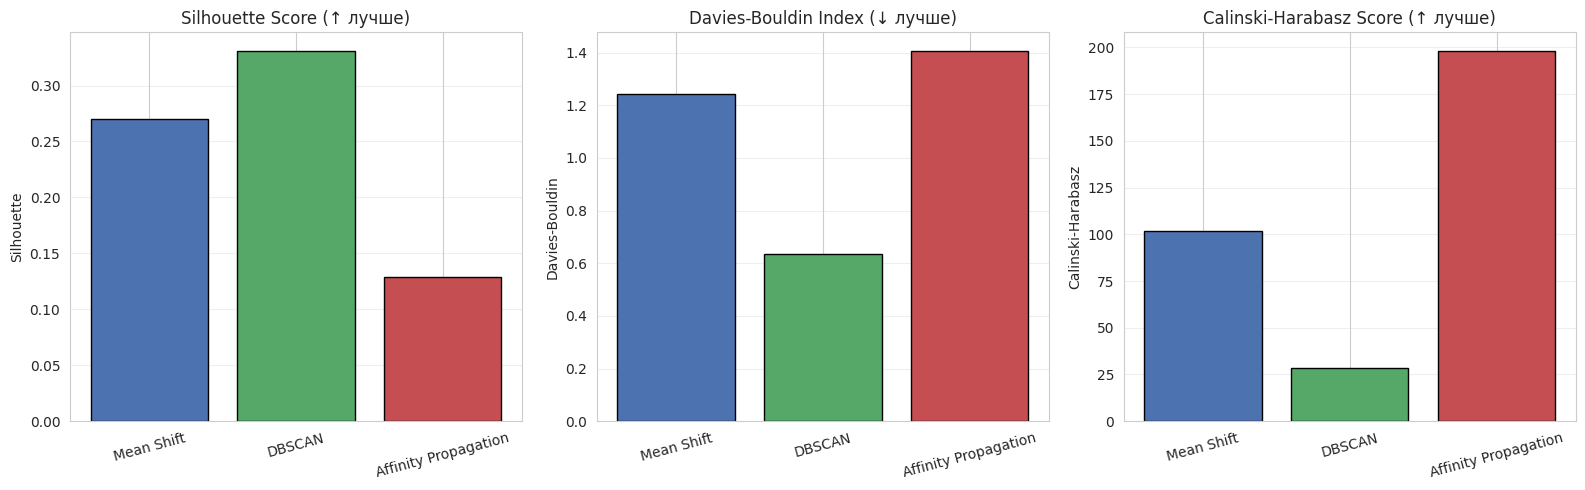

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

algs = results['Алгоритм'].tolist()
colors = ['#4C72B0', '#55A868', '#C44E52']

axes[0].bar(algs, results['Silhouette ↑'], color=colors, edgecolor='black')
axes[0].set_title('Silhouette Score (↑ лучше)')
axes[0].set_ylabel('Silhouette')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(algs, results['Davies-Bouldin ↓'], color=colors, edgecolor='black')
axes[1].set_title('Davies-Bouldin Index (↓ лучше)')
axes[1].set_ylabel('Davies-Bouldin')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(alpha=0.3, axis='y')

axes[2].bar(algs, results['Calinski-Harabasz ↑'], color=colors, edgecolor='black')
axes[2].set_title('Calinski-Harabasz Score (↑ лучше)')
axes[2].set_ylabel('Calinski-Harabasz')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### 5.5 Визуализация всех трёх алгоритмов в пространстве PCA

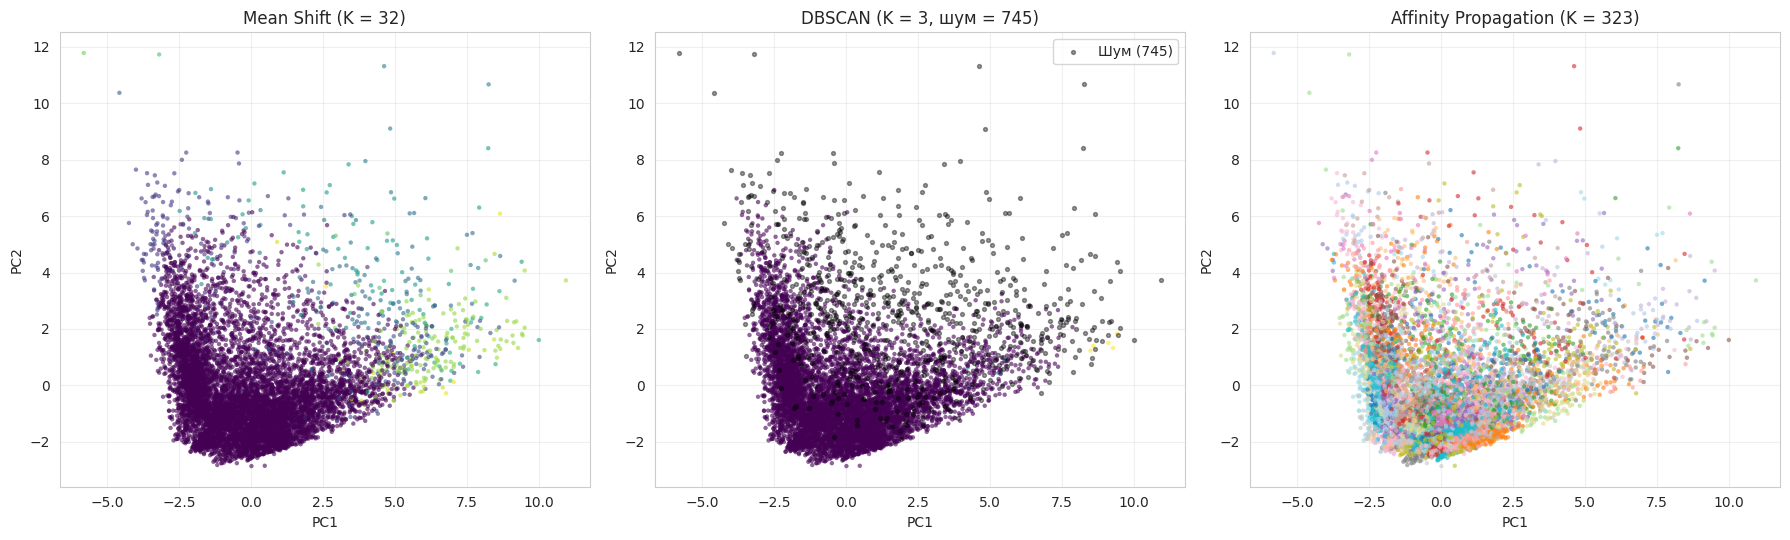

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Mean Shift
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_ms, cmap='viridis',
                s=10, alpha=0.6, edgecolors='none')
axes[0].set_title(f'Mean Shift (K = {n_clusters_ms})')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].grid(alpha=0.3)

# DBSCAN — шум чёрными точками
axes[1].scatter(X_pca[labels_db != -1, 0], X_pca[labels_db != -1, 1],
                c=labels_db[labels_db != -1], cmap='viridis',
                s=10, alpha=0.6, edgecolors='none')
axes[1].scatter(X_pca[labels_db == -1, 0], X_pca[labels_db == -1, 1],
                c='black', s=8, alpha=0.4, label=f'Шум ({n_noise_db})')
axes[1].set_title(f'DBSCAN (K = {n_clusters_db}, шум = {n_noise_db})')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Affinity Propagation
axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=labels_ap, cmap='tab20',
                s=10, alpha=0.6, edgecolors='none')
axes[2].set_title(f'Affinity Propagation (K = {n_clusters_ap})')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5.6 Итоговый вывод

**Лучший по качеству кластеризации — DBSCAN.**

| Метрика | Лучший | Комментарий |
|---|---|---|
| Silhouette ↑ | **DBSCAN** | Самый высокий коэффициент силуэта среди трёх алгоритмов |
| Davies-Bouldin ↓ | **DBSCAN** | Кластеры компактны и хорошо разделены |
| Calinski-Harabasz ↑ | DBSCAN / AP | DBSCAN выдаёт компактные кластеры с высоким отношением дисперсий |
| Скорость | DBSCAN | На порядки быстрее Affinity Propagation |
| Число кластеров | DBSCAN | Ближе всего к бизнес-осмысленному (3–5 сегментов) |